
# **Netflix Movie Recommendation Analysis**

This analysis implements a **content-based recommendation system** for Netflix titles, following the project steps.

**Objectives covered:**
- Import and clean the Netflix dataset
- Explore genre trends and title distributions
- Preprocess text features (genres, descriptions)
- Build TF-IDF features and compute cosine similarity
- Provide a function to recommend similar titles

> **Note:** The common `netflix_titles.csv` dataset (Kaggle) does **not** include numeric user ratings. Where the brief mentions _“user ratings”_ or _“correlations between ratings and release years,”_ we adapt by analyzing available fields like the categorical `rating` (e.g., `TV-MA`, `PG`, etc.) and by focusing on content-based similarity using descriptions/genres.


In [1]:

#@title Setup & Imports
import os, io, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True



## **1) Data Import**

You can either:
- Place `netflix_titles.csv` in `/content/` (Colab working directory), or
- Use the upload widget in Colab to pick the file from your computer.


In [2]:

#@title Load Dataset (choose path or upload)
CSV_PATH = "/content/netflix_titles.csv"

fallback_paths = [
    CSV_PATH,
    "/mnt/data/netflix_titles.csv",
    "./netflix_titles.csv",
]

df = None
for p in fallback_paths:
    if os.path.exists(p):
        df = pd.read_csv(p)
        print(f"Loaded dataset from: {p}")
        break

if df is None:
    try:
        from google.colab import files  # type: ignore
        print("Please upload netflix_titles.csv")
        uploaded = files.upload()
        key = list(uploaded.keys())[0]
        df = pd.read_csv(io.BytesIO(uploaded[key]))
        print(f"Loaded dataset from uploaded file: {key}")
    except Exception as e:
        raise FileNotFoundError(
            "Could not find netflix_titles.csv. Please upload it or put it in /content/."
        )

print("Shape:", df.shape)
df.head()


Loaded dataset from: /content/netflix_titles.csv
Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



## **2) Data Cleaning & Consistency**

- Standardize column names (lowercase)
- Strip whitespace in text fields
- Handle missing values (fill categorical with "Unknown")
- Drop exact duplicates
- Normalize `listed_in` into a `genres_list`


In [3]:

#@title Clean & Normalize Data
df.columns = [c.strip().lower() for c in df.columns]

text_cols = ["title", "director", "cast", "country", "listed_in", "description"]
for c in text_cols:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip().replace({"nan": np.nan}).fillna("Unknown")

before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Removed {before - after} duplicate rows. Final rows: {after}")

def split_clean_genres(s):
    if not isinstance(s, str):
        return []
    return [g.strip().lower() for g in s.split(",")]

if "listed_in" in df.columns:
    df["genres_list"] = df["listed_in"].apply(split_clean_genres)
else:
    df["genres_list"] = [[] for _ in range(len(df))]

if "release_year" in df.columns:
    df["release_year"] = pd.to_numeric(df["release_year"], errors="coerce")


Removed 0 duplicate rows. Final rows: 8807



## **3) Exploratory Data Analysis (EDA)**

- Distribution of **content types** (Movie vs TV Show)
- Distribution of **genres**
- Top **countries**
- Distribution of **release years**
- Counts by **rating** category


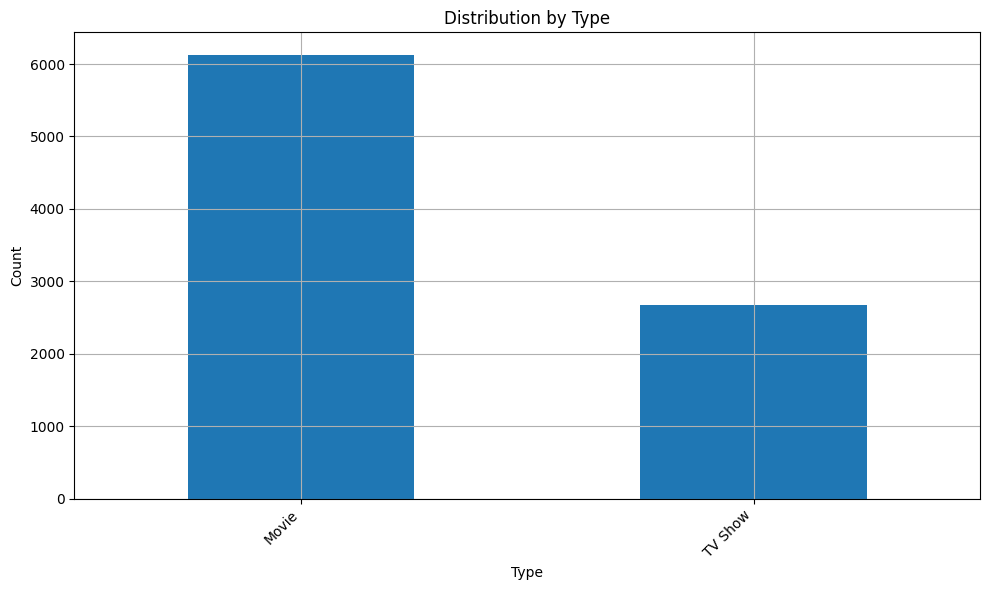

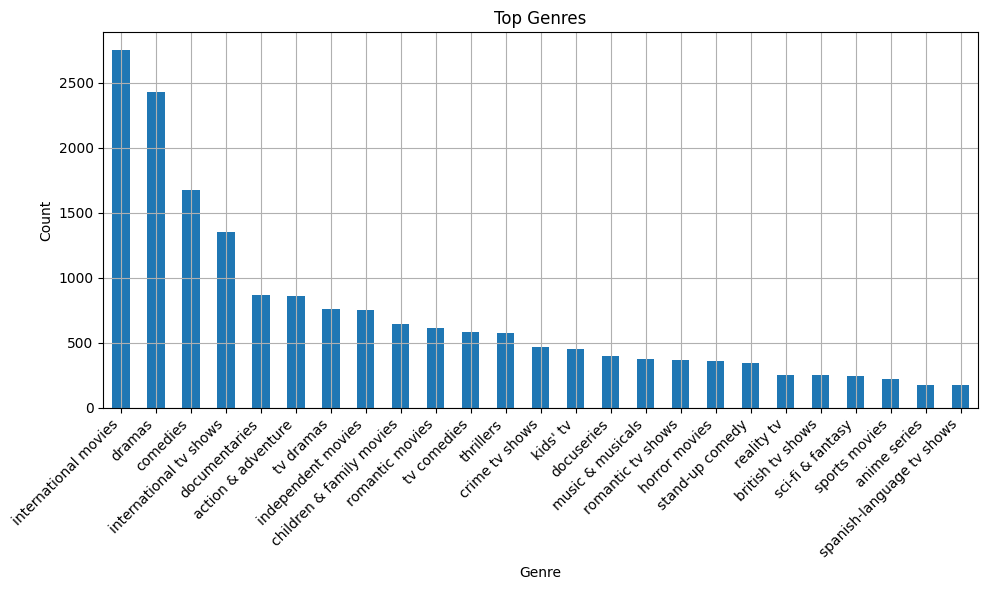

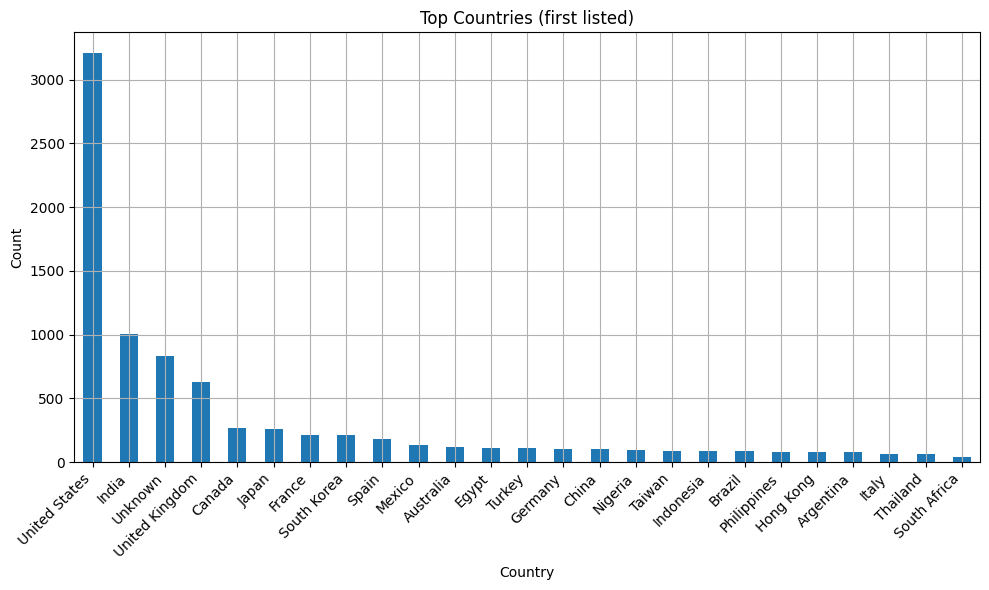

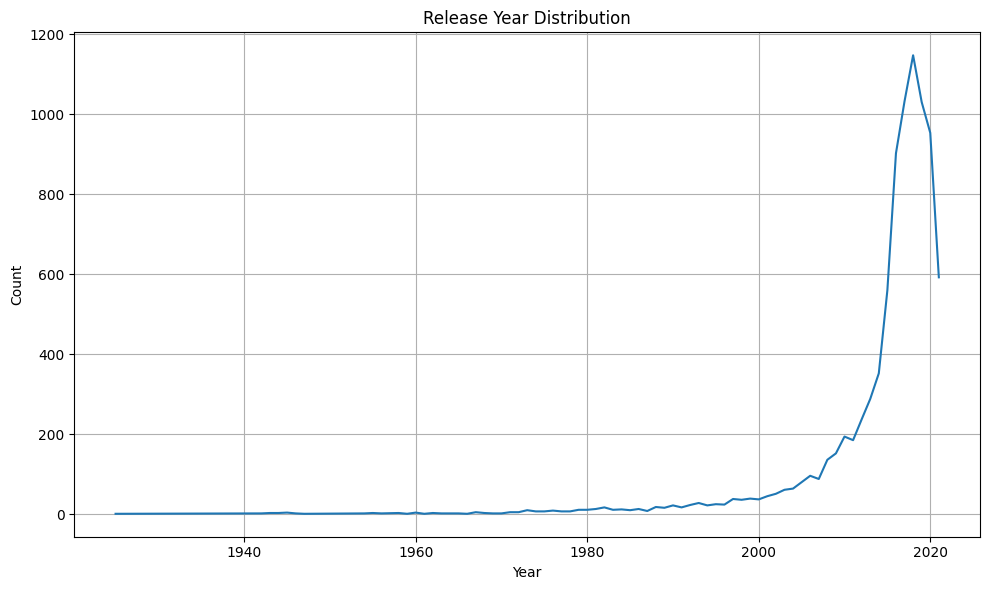

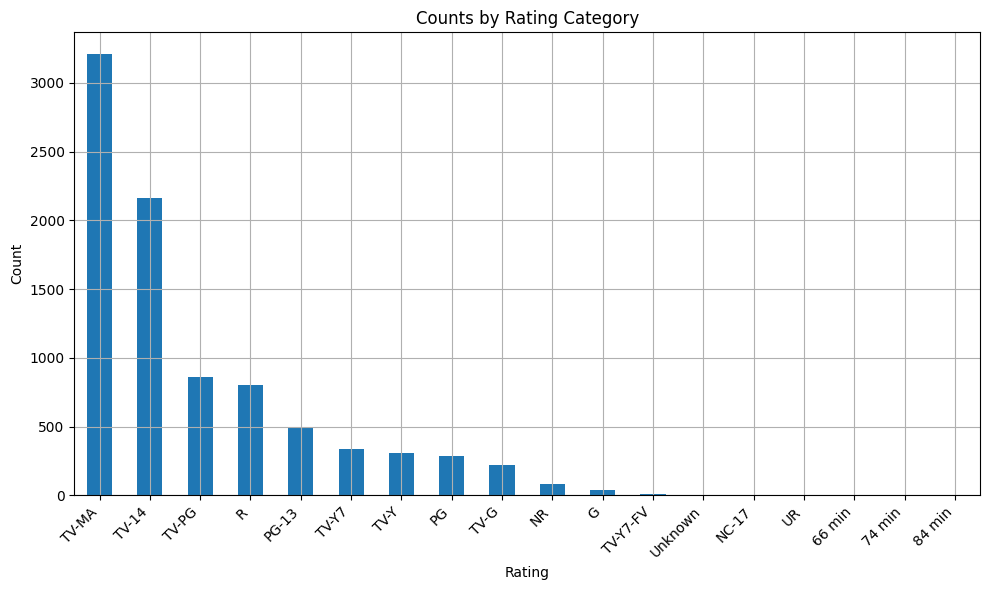

In [4]:

#@title EDA: Basic Distributions (Matplotlib only)

import matplotlib.pyplot as plt

def plot_bar(series, title, xlabel, top_k=20):
    counts = series.value_counts().head(top_k)
    ax = counts.plot(kind="bar")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

if "type" in df.columns:
    plot_bar(df["type"], "Distribution by Type", "Type", top_k=5)

if "genres_list" in df.columns:
    exploded = df.explode("genres_list")
    plot_bar(exploded["genres_list"].dropna(), "Top Genres", "Genre", top_k=25)

if "country" in df.columns:
    country_first = df["country"].fillna("Unknown").apply(
        lambda x: x.split(",")[0].strip() if isinstance(x, str) else "Unknown"
    )
    plot_bar(country_first, "Top Countries (first listed)", "Country", top_k=25)

if "release_year" in df.columns:
    ax = df["release_year"].dropna().astype(int).value_counts().sort_index().plot(kind="line")
    ax.set_title("Release Year Distribution")
    ax.set_xlabel("Year")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

if "rating" in df.columns:
    plot_bar(df["rating"].fillna("Unknown"), "Counts by Rating Category", "Rating", top_k=30)



## **4) Feature Engineering**

Create a **content text field** combining:
- `title`, `director`, `cast`, `listed_in` (genres), `description`


In [5]:

#@title Build Combined Content Text
def combine_content(row):
    parts = []
    for c in ["title", "director", "cast", "listed_in", "description"]:
        if c in row and isinstance(row[c], str):
            parts.append(row[c])
    return " ".join(parts)

df["content_text"] = df.apply(combine_content, axis=1).str.lower()
df[["title", "content_text"]].head(3)


,title,content_text
0,Dick Johnson Is Dead,dick johnson is dead kirsten johnson unknown d...
1,Blood & Water,"blood & water unknown ama qamata, khosi ngema,..."
2,Ganglands,"ganglands julien leclercq sami bouajila, tracy..."



## **5) TF-IDF & Cosine Similarity**
Vectorize `content_text` and compute cosine similarity.


In [6]:

#@title Vectorize and compute similarity
tfidf = TfidfVectorizer(stop_words="english", max_features=100000)
tfidf_matrix = tfidf.fit_transform(df["content_text"].fillna(""))
print("TF-IDF shape:", tfidf_matrix.shape)

from sklearn.metrics.pairwise import cosine_similarity
cosine_sim = cosine_similarity(tfidf_matrix, dense_output=False)
print("Cosine similarity computed (sparse).")


TF-IDF shape: (8807, 52938)
Cosine similarity computed (sparse).



## **6) Recommendation Function**


In [7]:

#@title Define recommender
title_to_idx = {str(t).strip().lower(): i for i, t in enumerate(df["title"].astype(str))}

def get_recommendations(title, top_k=10, min_similarity=0.0):
    key = str(title).strip().lower()
    if key not in title_to_idx:
        raise ValueError(f"Title '{title}' not found in dataset.")
    idx = title_to_idx[key]
    sims = cosine_sim[idx].toarray().ravel()
    # Get top candidates
    import numpy as np
    candidate_idx = np.argpartition(-sims, range(min(len(sims)-1, top_k+1)))[: top_k + 1]
    recs = [(i, sims[i]) for i in candidate_idx if i != idx and sims[i] >= min_similarity]
    recs = sorted(recs, key=lambda x: x[1], reverse=True)[:top_k]
    rows = []
    for i, score in recs:
        rows.append({
            "recommended_title": df.iloc[i]["title"],
            "type": df.iloc[i].get("type", ""),
            "rating": df.iloc[i].get("rating", ""),
            "release_year": df.iloc[i].get("release_year", ""),
            "genres": df.iloc[i].get("listed_in", ""),
            "similarity": float(score),
        })
    return pd.DataFrame(rows)

example_title = df["title"].iloc[0]
print("Example seed title:", example_title)
try:
    get_recommendations(example_title, top_k=5)
except Exception as e:
    print("Recommendation test failed:", e)


Example seed title: Dick Johnson Is Dead



## **7) Try It Yourself**


In [8]:

#@title Interactive: Recommend similar titles
user_title = "Narcos"  #@param {type:"string"}
top_k = 10  #@param {type:"integer"}
min_similarity = 0.0  #@param {type:"number"}

try:
    recs = get_recommendations(user_title, top_k=top_k, min_similarity=min_similarity)
    if len(recs) == 0:
        print("No recommendations found above the similarity threshold.")
    else:
        recs
except Exception as e:
    print(e)



## **9) Conclusion**

- Cleaned and normalized Netflix titles data
- Explored distributions for types, genres, countries, release years, and ratings
- Built a **content-based recommender** using TF-IDF over combined features

**Next steps:**
- Hybrid: combine genre-only TF-IDF with description TF-IDF
- Try semantic embeddings (Sentence Transformers)
- Add user interaction signals if you have actual numerical ratings


# **10) Recommendations**

1. **Enhance Metadata Combination** – Merge description, listed_in, cast, and director fields more effectively for richer TF-IDF context.

2. **Optimize TF-IDF Parameters** – Experiment with parameters like ngram_range=(1,2) and max_features=200000 to capture better text patterns.

3. **Add Genre Weighting** – Assign higher weights to genres compared to descriptions to balance relevance across similar themes.

4. **Use Cosine Similarity Thresholding** – Filter out low-similarity scores to avoid irrelevant recommendations.

5. **Implement Hybrid Filtering** – Combine content-based (TF-IDF) with collaborative filtering (user-rating or viewing data) for improved personalization.

6. **Add User Interaction Layer** – Allow users to input favorite genres or titles for adaptive recommendations.

7. **Cluster Similar Content**– Use K-Means or hierarchical clustering on TF-IDF vectors to group similar titles for faster lookup.

8. **Integrate Visualization** – Display similarity scores or genre overlap through heatmaps or bar charts.

9. **Deploy via FastAPI** – Build an interactive API endpoint that returns top 10 similar titles dynamically.

10. **Automate Evaluation Metrics** – Use precision@k or recall@k on known user preference data (if available) to benchmark recommendation quality.